#  SWIGGY SALES ANALYSIS 

### Import Library   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Import Data   

In [3]:
df = pd.read_excel("D:/Downloads/swiggy_data.xlsx")

In [4]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [5]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### Meta Data   

In [9]:
print("No of Rows:",df.shape[0])
print("No of Fields:",df.shape[1])


No of Rows: 197430
No of Fields: 10


In [10]:
df.info


<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

### Data Type  

In [11]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

## KPI's  

### Total Sales

In [18]:
total_sales = df["Price (INR)"].sum()
print("Total sales(INR) :", round(total_sales,2))

Total sales(INR) : 53012505.77


### Average Rating

In [17]:
avg_rating = df["Rating"].mean()
print("Average Rating :",round(avg_rating,2))

Average Rating : 4.34


### Rating Count

In [16]:
rating_count = df["Rating Count"].sum()
print("Rating Count :",round(rating_count,2))

Rating Count : 5591574


### Total Order 

In [20]:
total_Orders = df["Price (INR)"].count()
print("Total Orders :", round(total_Orders,2))

Total Orders : 197430


In [22]:
total_Orders = len(df)
print("Total Orders :", round(total_Orders,2))

Total Orders : 197430


### Average Order Value

In [19]:
avg_Order_Value = df["Price (INR)"].mean()
print("Average Order Value :",round(avg_Order_Value,2))

Average Order Value : 268.51


# Charts Design

### Monthly Sales Trend

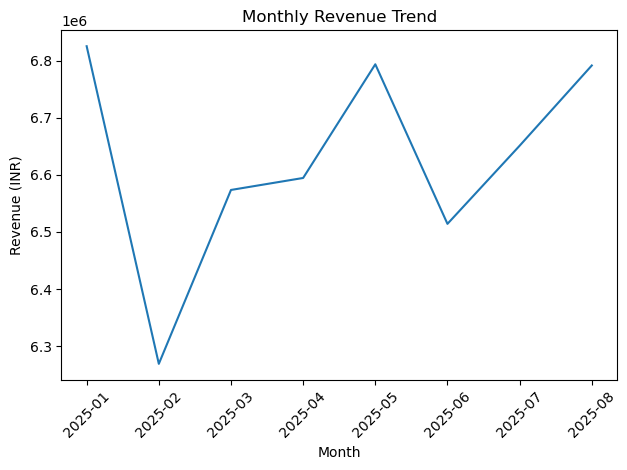

In [23]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

### Daily Sales Trend

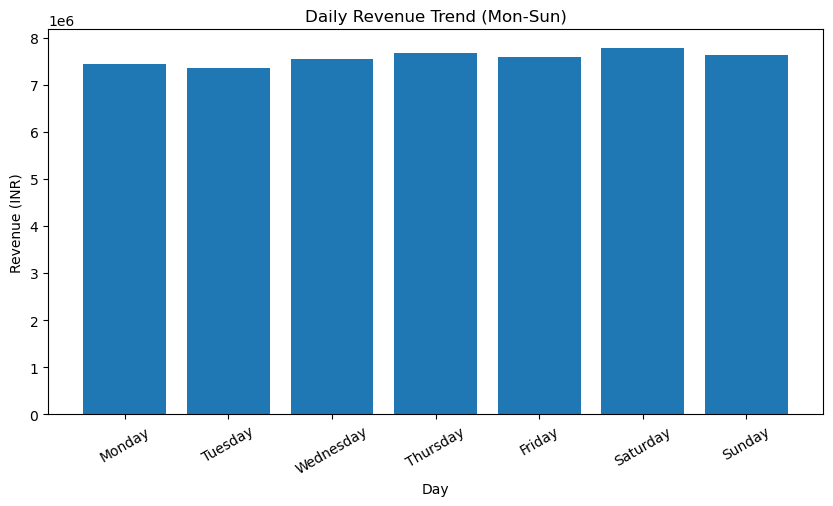

In [27]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

# Define the correct order of days
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_revenue = (
    df.groupby("DayName")["Price (INR)"]
        .sum()
        .reset_index()
)

# Reorder the days to be in sequence (Monday to Sunday)
daily_revenue["DayName"] = pd.Categorical(daily_revenue["DayName"], categories=day_order, ordered=True)
daily_revenue = daily_revenue.sort_values("DayName")

plt.figure(figsize=(10,5))
plt.bar(daily_revenue["DayName"], daily_revenue["Price (INR)"])
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)

plt.show()

### Total Sales by Food Type (Veg vs Non-Veg)

In [30]:
non_veg_keywords = ["chicken","fish","egg","mutton","prawn",
                    "biryani","kabab","kebab","non-veg","non veg"]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords),na=False),
    "Non-veg",
    "veg"
)

In [31]:
food_revenue = (
    df.groupby("Food Category")["Price (INR)"]
    .sum()
    .reset_index()
)

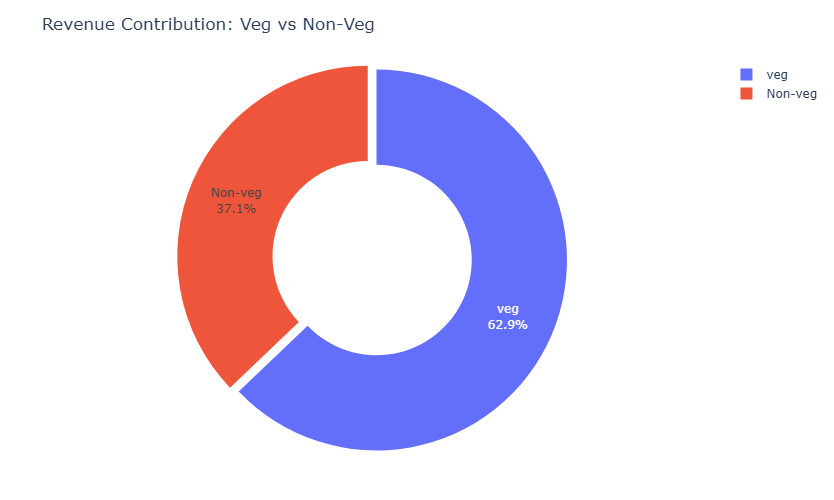

In [32]:
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0]
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.show()

### Total Sales by State

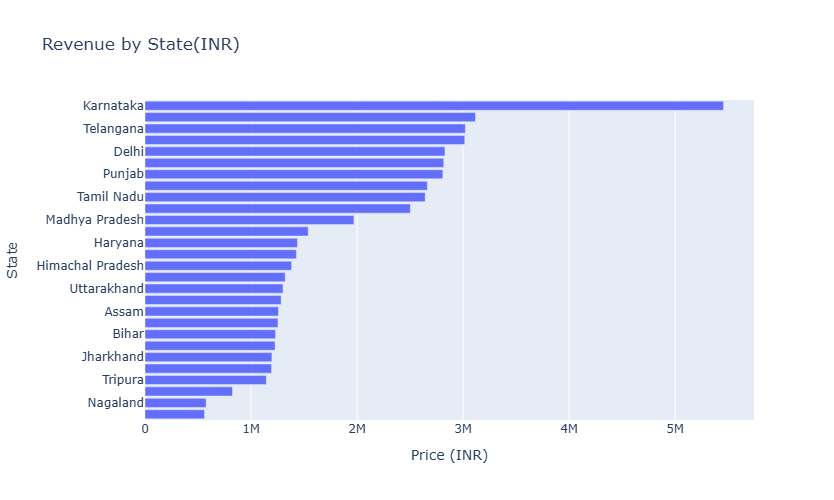

In [33]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
    .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State(INR)")

fig.update_layout(height=500, yaxis=dict(autorange="reversed"))
fig.show()

### Quarterly Performance Summary

In [35]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)
Quarterly_summary = (
    df.groupby("Quarter", as_index=False)
    .agg(
        Total_Sales=("Price (INR)", "sum"),
        Avg_Rating=("Rating", "mean"),
        Total_Orders=("Order_Date", "count")
    )
    .sort_values("Quarter")
)
Quarterly_summary["Total_Sales"] = Quarterly_summary["Total_Sales"].round(0)
Quarterly_summary["Avg_Rating"] = Quarterly_summary["Avg_Rating"].round(2)

Quarterly_summary



,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


### Top 5 Cities by Sales

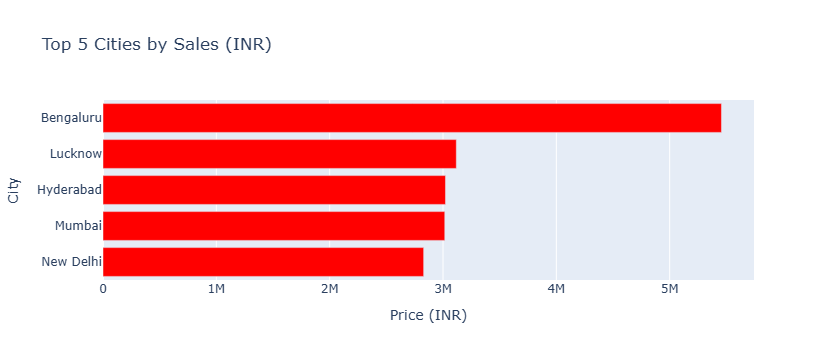

In [40]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"])


fig.show()